In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy import stats
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import spacy

In [ ]:
# Install Gradio
!pip install gradio -qq
print("Gradio installed successfully!")

Gradio installed successfully!


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/water_potability.csv')
print(df.head())
print(df.describe())
df.isnull().sum()

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean     

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [ ]:

df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())
print("The amount of null values are:", df.isnull().sum().sum())
df.head(15)

The amount of null values are: 0


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,7.080795,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


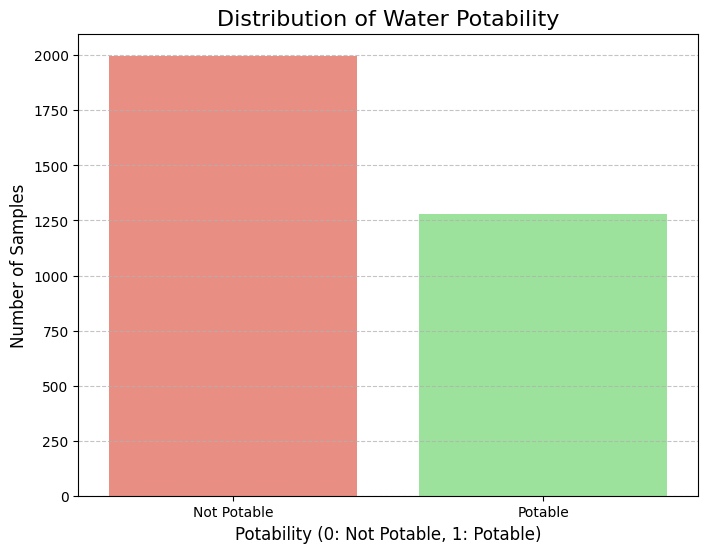

In [ ]:
potability_counts = df['Potability'].value_counts()
plt.figure(figsize=(8, 6))
sea.barplot(x=potability_counts.index, y=potability_counts.values, hue=
potability_counts.index, palette=['salmon', 'lightgreen'], legend=False)
plt.title('Distribution of Water Potability', fontsize=16)
plt.xlabel('Potability (0: Not Potable, 1: Potable)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Not Potable', 'Potable'])
plt.grid(axis='y', linestyle='--', alpha=0.75)
plt.show()

In [ ]:
y=df['Potability']
X=df.iloc[:,:-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = RandomForestClassifier(class_weight='balanced', random_state=42)
param_dist = {
    'n_estimators': stats.randint(100, 751),
    'max_depth': list(np.arange(10, 61)) + [None],
    'min_samples_split': stats.randint(2, 26),
    'min_samples_leaf': stats.randint(1, 16)
}
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=200, cv=5, scoring='roc_auc', random_state=42)
random_search.fit(X_train_scaled, y_train)

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sea
features_to_compare = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
mean_comparison = df.groupby('Potability')[features_to_compare].mean().T.reset_index()
mean_comparison.columns = ['Feature', 'Non_Potable', 'Potable']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
axes = axes.flatten()
for i, feature in enumerate(features_to_compare):
    data_for_plot = mean_comparison[mean_comparison['Feature'] == feature]
    melted_data = data_for_plot.melt(id_vars=['Feature'], var_name='Potability_Status', value_name='Mean_Value')
    sea.barplot(x='Potability_Status', y='Mean_Value', data=melted_data, ax=axes[i], palette='coolwarm', hue='Potability_Status', legend=False)
    axes[i].set_title(f'Mean {feature} by Potability', fontsize=14)
    axes[i].set_xlabel('Potability (0=Non-Potable, 1=Potable)', fontsize=10)
    axes[i].set_ylabel(f'Mean {feature} Value', fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Potable', 'Potable'], rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
random_search.fit(X_train_scaled,y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

y_pred=random_search.best_estimator_.predict(X_test_scaled)
y_pred_proba=random_search.best_estimator_.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})
plt.figure(figsize=(10, 6))
sea.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
plt.title('Key Classification Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
y_pred=random_search.best_estimator_.predict(X_test_scaled)
y_pred_proba=random_search.best_estimator_.predict_proba(X_test_scaled)
print(classification_report(y_test,y_pred))
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"ROC AUC Score: {roc_auc:.4f}")


In [ ]:
import joblib

# Define file paths for saving
model_filename = '/content/drive/MyDrive/random_forest_model.joblib'
scaler_filename = '/content/drive/MyDrive/scaler.joblib'

# Save the best estimator (trained model) from RandomizedSearchCV
# This line will now only execute if random_search has been successfully fitted.
if hasattr(random_search, 'best_estimator_'):
    joblib.dump(random_search.best_estimator_, model_filename)
    print(f"Trained Random Forest model saved to: {model_filename}")
else:
    print("Error: random_search.best_estimator_ is not available. Ensure RandomizedSearchCV was fitted successfully.")

# Save the scaler
joblib.dump(scaler, scaler_filename)
print(f"StandardScaler saved to: {scaler_filename}")

In [ ]:
import gradio as gr
import re

nlp_responses = {
    "ph": "To measure **pH** in water, you can use:\n- **pH Test Strips:** Inexpensive and easy to use, just dip and compare color.\n- **Liquid pH Test Kits:** More accurate than strips, involves adding drops to a water sample.\n- **Digital pH Meter:** Most accurate and reliable, requires calibration but provides precise readings.",
    "hardness": "To measure **Hardness** in water, you can use:\n- **Hardness Test Strips:** Similar to pH strips, they change color based on calcium and magnesium levels.\n- **Liquid Titration Kits:** More precise, involves dropping a reagent into a water sample until a color change indicates endpoint.\n- **Professional Lab Testing:** For highly accurate measurements.",
    "solids": "To measure **Total Dissolved Solids (TDS)** in water, you can use:\n- **TDS Meter:** An electronic device that measures electrical conductivity, which correlates to TDS levels. Ensure it's calibrated.\n- **Evaporation Method (Lab):** A precise method where a water sample is evaporated, and the remaining residue is weighed.",
    "chloramines": "**Chloramines** are usually measured in water systems by:\n- **DPD Test Kits:** These kits use reagents that react with chlorine and chloramines to produce a color, which is then compared to a color chart or read by a colorimeter.\n- **Spectrophotometers:** For laboratory-grade accuracy.",
    "sulfate": "**Sulfate** levels in water are typically measured by:\n- **Colorimetric Test Kits:** These kits use a reagent that reacts with sulfate to produce a turbidity or color, measured against a standard.\n- **Turbidimetric Method (Lab):** Involves precipitating sulfate as barium sulfate and measuring the turbidity.\n- **Ion Chromatography (Lab):** For precise quantification of various ions, including sulfate.",
    "organic carbon": "**Total Organic Carbon (TOC)** in water is measured using specialized analytical instruments:\n- **TOC Analyzers:** These instruments oxidize organic carbon to carbon dioxide and then measure the CO2. This is primarily a laboratory method.",
    "trihalomethanes": "**Trihalomethanes (THMs)** are disinfection byproducts and require sophisticated laboratory analysis:\n- **Gas Chromatography-Mass Spectrometry (GC-MS):** This is the standard method for identifying and quantifying THMs in water samples.",
    "turbidity": "**Turbidity** in water is measured with:\n- **Turbidimeters (Nephelometers):** These devices measure the amount of light scattered by suspended particles in the water sample, providing results in Nephelometric Turbidity Units (NTU).\n- **Secchi Disk (Field Method):** A simpler, less precise field method for surface water clarity."
}

def get_measurement_info(query):
    query_lower = query.lower()
    for param, info in nlp_responses.items():
        if param in query_lower or re.search(r'\b' + param.replace('_', ' ') + r'\b', query_lower):
            return info

    return "I'm sorry, I don't have specific information on how to measure that parameter. Please try asking about pH, Hardness, Solids, Chloramines, Sulfate, Organic Carbon, Trihalomethanes, or Turbidity."

nlp_interface = gr.Interface(
    fn=get_measurement_info,
    inputs=gr.Textbox(lines=2, placeholder="Ask how to find a water quality parameter (e.g., 'how to measure pH in water?')"),
    outputs=gr.Markdown(),
    title="Water Quality Parameter Measurement Guide",
    description="Ask how to measure different water quality parameters (e.g., pH, Hardness, Solids, etc.) and get guidance."
)

nlp_interface.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a41a8bdae3527ccdfa.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Step 2: Create the Gradio Application

Now, let's create a Python script for the Gradio interface. This script will:

1.  Load the saved model and scaler.
2.  Define a prediction function that takes all water quality parameters as input.
3.  Preprocess the input using the loaded scaler.
4.  Make a prediction and generate a user-friendly output, including general suggestions if the water is not potable.
5.  Set up the Gradio interface with appropriate input fields and an output display.

In [ ]:
import gradio as gr
import pandas as pd
import joblib

# Load the saved model and scaler
loaded_model = joblib.load('/content/drive/MyDrive/random_forest_model.joblib')
loaded_scaler = joblib.load('/content/drive/MyDrive/scaler.joblib')

# Define the prediction function for the Gradio interface
def predict_potability(
    ph,
    Hardness,
    Solids,
    Chloramines,
    Sulfate,
    Conductivity,
    Organic_carbon,
    Trihalomethanes,
    Turbidity
):
    # Create a DataFrame from the inputs, matching the order of features used during training
    input_data = pd.DataFrame([[ph, Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic_carbon, Trihalomethanes, Turbidity]],
                              columns=['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity'])

    # Scale the input data using the loaded scaler
    scaled_input = loaded_scaler.transform(input_data)

    # Make a prediction
    prediction = loaded_model.predict(scaled_input)[0]
    prediction_proba = loaded_model.predict_proba(scaled_input)[0]

    output_text = ""
    if prediction == 1:
        output_text += f"The water is **Potable**! (Confidence: {prediction_proba[1]*100:.2f}%)"
    else:
        output_text += f"The water is **NOT Potable**. (Confidence: {prediction_proba[0]*100:.2f}%)\n\n"
        output_text += "**Suggestions to improve potability:**\n"
        output_text += "- **pH Adjustment:** Ensure pH is within the acceptable range (6.5 to 8.5) through aeration or chemical treatment.\n"
        output_text += "- **Hardness Reduction:** Consider water softening methods like ion exchange or reverse osmosis.\n"
        output_text += "- **Solid Removal:** Implement filtration (e.g., sand filtration, membrane filtration) to reduce dissolved solids.\n"
        output_text += "- **Disinfection Optimization:** Monitor chloramine levels carefully to ensure effective disinfection without excess.\n"
        output_text += "- **Sulfate Control:** If sulfate levels are high, consider reverse osmosis or distillation.\n"
        output_text += "- **Organic Carbon Management:** Use activated carbon filtration or advanced oxidation processes.\n"
        output_text += "- **Trihalomethane Reduction:** Improve source water quality, optimize disinfection, or use activated carbon filters.\n"
        output_text += "- **Turbidity Control:** Enhance coagulation, flocculation, sedimentation, and filtration processes."
    return output_text

# Interface for Potability Prediction
potability_interface = gr.Interface(
    fn=predict_potability,
    inputs=[
        gr.Slider(minimum=0.0, maximum=14.0, step=0.1, label="pH"),
        gr.Slider(minimum=0.0, maximum=500.0, step=0.1, label="Hardness (mg/L)"),
        gr.Slider(minimum=0.0, maximum=70000.0, step=1.0, label="Solids (ppm)"),
        gr.Slider(minimum=0.0, maximum=15.0, step=0.01, label="Chloramines (ppm)"),
        gr.Slider(minimum=0.0, maximum=500.0, step=0.1, label="Sulfate (mg/L)"),
        gr.Slider(minimum=0.0, maximum=1000.0, step=0.1, label="Conductivity (μS/cm)"),
        gr.Slider(minimum=0.0, maximum=30.0, step=0.01, label="Organic Carbon (ppm)"),
        gr.Slider(minimum=0.0, maximum=150.0, step=0.01, label="Trihalomethanes (μg/L)"),
        gr.Slider(minimum=0.0, maximum=10.0, step=0.01, label="Turbidity (NTU)")
    ],
    outputs=gr.Markdown("text"),
    title="Water Potability Predictor",
    description="Enter the water quality parameters to predict if the water is potable and get suggestions if not."
)

potability_interface.launch(share=True, debug=True)


### Step 3: Run the Gradio Application

After executing the cell above, Gradio will provide a public URL (or a local URL if you're running locally) where you can access your interactive interface. Click on that link to start using your AI-powered water potability predictor!